# Train the stacked RNN next-step predictor (with actions)

Trains `StackedRNNPredictor` on rollouts driven by a `RandomShiftPolicy`. Each
layer's recurrence is conditioned on the per-timestep action:

    h(t+1) = tau*h(t) + tanh((1 - tau) * encoder(h(t) + noise, input(t), action(t)))

The action at step t modifies the stimulus at step t+1, so this is an
action-conditioned next-step prediction. Optionally the one-hot of the executed
action is appended to the following input (`USE_ACTION_FEEDBACK`).

- **Layer 0** next-step predicts the (action-driven) stimulus.
- **Each higher layer** auto-encodes the layer below it, and is conditioned on
  the same action. All layers run over length T, aligned to the action sequence.

Set the task with `TASK`, the depth with `HIDDEN_DIMS`, and the policy with
`ACTION_PROBABILITY`.


## Config

In [1]:
# --- task choice ---
TASK = 'drift'   # 'binary_noise' | 'drift' | 'gaussian_process'

# --- task / data ---
VECTOR_LENGTH = 12
SEQ_LEN       = 80
NUM_TRAIN_SEQ = 256
NUM_EVAL_SEQ  = 1
SEED          = 0

# --- policy / actions ---
ACTION_PROBABILITY  = 0.2    # RandomShiftPolicy: prob of a left/right shift each step
USE_ACTION_FEEDBACK = True   # append one-hot of the executed action to the next input

# --- model ---
HIDDEN_DIMS = [64, 64, 64]   # one entry per layer -> 3 layers by default
INITIALIZER_HIDDEN_SIZES = [64, 64]   # hidden sizes of the state-init MLPs
TAU         = 0.9
NOISE_STD   = 0.1
DECODER_SCALE_INPUT  = 2.0   # layer-0 decoder saturates here (covers [0, 1] stimuli)
DECODER_SCALE_LATENT = 3.0   # higher-layer decoders saturate here (cover latents ~ +/-1)

# --- training ---
NUM_EPOCHS    = 200
BATCH_SIZE    = 64
LEARNING_RATE = 3e-3

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from tasks import (BinaryNoiseTask, DriftTask, GaussianProcessTask,
                   RandomShiftPolicy, rollout)
from tasks.actions import ACTION_DIM, NONE, LEFT, RIGHT, one_hot, feedback
from models import StackedRNNPredictor

torch.manual_seed(SEED)

## Build data from policy rollouts

Each example is an independent rollout of the chosen task under the policy,
giving an observation sequence and the action sequence that drove it. The model
input is the observation, optionally augmented with action feedback; the actions
are one-hot encoded for the recurrence.


In [3]:
def make_task():
    if TASK == 'binary_noise':
        return BinaryNoiseTask(vector_length=VECTOR_LENGTH, prob=0.3, resample_prob=0.1)
    if TASK == 'drift':
        return DriftTask(vector_length=VECTOR_LENGTH, prob=0.3)
    if TASK == 'gaussian_process':
        return GaussianProcessTask(vector_length=VECTOR_LENGTH,
                                   spatial_temperature=3.0, temporal_temperature=5.0)
    raise ValueError(f'unknown TASK: {TASK}')


def make_dataset(num_seq, base_seed):
    policy = RandomShiftPolicy(action_probability=ACTION_PROBABILITY)
    rollouts = [rollout(make_task(), policy, SEQ_LEN, seed=base_seed + i) for i in range(num_seq)]
    obs = np.stack([o for o, _ in rollouts])
    acts = np.stack([a for _, a in rollouts])
    return obs, acts


def build_tensors(obs, acts):
    codes = np.stack([one_hot(a) for a in acts])          # (N, T, ACTION_DIM)
    x = obs
    if USE_ACTION_FEEDBACK:
        fb = np.stack([feedback(a) for a in acts])        # (N, T, ACTION_DIM)
        x = np.concatenate([obs, fb], axis=-1)
    return (torch.tensor(x, dtype=torch.float32),
            torch.tensor(codes, dtype=torch.float32))


train_obs, train_acts = make_dataset(NUM_TRAIN_SEQ, base_seed=1000)
eval_obs,  eval_acts  = make_dataset(NUM_EVAL_SEQ,  base_seed=9000)

train_x, train_A = build_tensors(train_obs, train_acts)
eval_x,  eval_A  = build_tensors(eval_obs,  eval_acts)

INPUT_DIM = VECTOR_LENGTH + (ACTION_DIM if USE_ACTION_FEEDBACK else 0)
print('train_x', tuple(train_x.shape), 'train_A', tuple(train_A.shape), 'INPUT_DIM', INPUT_DIM)

train_x (256, 80, 14) train_A (256, 80, 2) INPUT_DIM 14


## Build the model

In [4]:
decoder_scale = [DECODER_SCALE_INPUT] + [DECODER_SCALE_LATENT] * (len(HIDDEN_DIMS) - 1)

model = StackedRNNPredictor(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS,
                            action_dim=ACTION_DIM,
                            initializer_hidden_sizes=INITIALIZER_HIDDEN_SIZES,
                            tau=TAU, noise_std=NOISE_STD, decoder_scale=decoder_scale)
NUM_LAYERS = model.num_layers
print(f'{NUM_LAYERS} layers, hidden dims {HIDDEN_DIMS}, action_dim {ACTION_DIM}, '
      f'feedback={USE_ACTION_FEEDBACK}')

3 layers, hidden dims [64, 64, 64], action_dim 2, feedback=True


## Train

Each layer has its own L1 next-step objective; `compute_loss` sums them, and the
per-layer gradients stay separate (higher layers consume detached latents).


In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

losses = [[] for _ in range(NUM_LAYERS)]
model.train()
for epoch in range(NUM_EPOCHS):
    perm = torch.randperm(train_x.shape[0])
    epoch_terms = np.zeros(NUM_LAYERS)
    num_batches = 0
    for start in range(0, train_x.shape[0], BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        optimizer.zero_grad()
        terms = model.loss_terms(train_x[idx], train_A[idx])
        sum(terms).backward()
        optimizer.step()
        epoch_terms += np.array([t.item() for t in terms])
        num_batches += 1
    epoch_terms /= num_batches
    for i in range(NUM_LAYERS):
        losses[i].append(epoch_terms[i])
    if (epoch + 1) % 50 == 0 or epoch == 0:
        line = '  '.join(f'L{i}={epoch_terms[i]:.4f}' for i in range(NUM_LAYERS))
        print(f'epoch {epoch + 1:4d}  {line}')

epoch    1  L0=0.3947  L1=0.1485  L2=0.1190


epoch   50  L0=0.1197  L1=0.0137  L2=0.0071


epoch  100  L0=0.1050  L1=0.0106  L2=0.0046


epoch  150  L0=0.1037  L1=0.0102  L2=0.0034


epoch  200  L0=0.1011  L1=0.0104  L2=0.0029


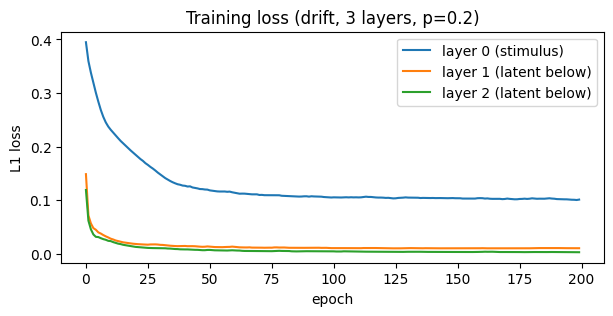

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
for i in range(NUM_LAYERS):
    label = 'layer 0 (stimulus)' if i == 0 else f'layer {i} (latent below)'
    ax.plot(losses[i], label=label)
ax.set_xlabel('epoch'); ax.set_ylabel('L1 loss')
ax.set_title(f'Training loss ({TASK}, {NUM_LAYERS} layers, p={ACTION_PROBABILITY})')
ax.legend()
plt.show()

## Evaluate and visualize

`eval()` mode disables the latent noise. Predictions are aligned so
`prediction[t]` sits against its target `input[t+1]`. Heatmaps show only the
stimulus part of the input (the feedback columns, if any, are omitted).


In [7]:
model.eval()
with torch.no_grad():
    out = model(eval_x, eval_A)

inputs = [out['inputs'][i][0].numpy() for i in range(NUM_LAYERS)]
preds  = [out['predictions'][i][0].numpy() for i in range(NUM_LAYERS)]
hidden = [out['hidden'][i][0].numpy() for i in range(NUM_LAYERS)]
acts_eval = eval_acts[0]

# Layer 0 metric on the stimulus part only (exclude feedback columns).
stim_pred   = preds[0][:-1, :VECTOR_LENGTH]
stim_target = inputs[0][1:, :VECTOR_LENGTH]
layer0_l1 = float(np.abs(stim_pred - stim_target).mean())
print(f'layer 0 eval mean L1 (stimulus): {layer0_l1:.4f}')
for i in range(1, NUM_LAYERS):
    v = float(np.abs(preds[i][:-1] - inputs[i][1:]).mean())
    print(f'layer {i} eval mean L1 (layer-{i-1} latent): {v:.4f}')

layer 0 eval mean L1 (stimulus): 0.0721
layer 1 eval mean L1 (layer-0 latent): 0.0078
layer 2 eval mean L1 (layer-1 latent): 0.0015


In [8]:
# Plotting helper: heatmap panels with an aligned "action executed" strip on top.
# A dedicated colorbar column keeps every panel (and the strip) at the same
# x-extent, so timesteps line up vertically across all rows.
_ACTION_RGB = {NONE: (1, 1, 1), LEFT: (0.20, 0.40, 0.85), RIGHT: (0.85, 0.25, 0.20)}

def plot_panels_with_actions(panels, strip_actions, panel_height=2.6):
    n = len(panels)
    T = panels[0]['data'].shape[0]
    strip_actions = np.asarray(strip_actions)
    fig = plt.figure(figsize=(10, 1.0 + panel_height * n))
    gs = fig.add_gridspec(n + 1, 2, width_ratios=[40, 1],
                          height_ratios=[1] + [8] * n, hspace=0.55, wspace=0.04)

    ax_strip = fig.add_subplot(gs[0, 0])
    strip_rgb = np.array([_ACTION_RGB[int(a)] for a in strip_actions])[None, :, :]
    ax_strip.imshow(strip_rgb, aspect='auto', interpolation='nearest', extent=[-0.5, T - 0.5, 0, 1])
    ax_strip.set_yticks([])
    ax_strip.set_title('action executed  (blue = left, red = right, blank = none)')

    axes = []
    for k, p in enumerate(panels):
        ax = fig.add_subplot(gs[k + 1, 0], sharex=ax_strip)
        im = ax.imshow(p['data'].T, aspect='auto', cmap=p['cmap'],
                       vmin=p.get('vmin'), vmax=p.get('vmax'), interpolation='nearest')
        ax.set_title(p['title'])
        ax.set_ylabel(p.get('ylabel', 'element'))
        fig.colorbar(im, cax=fig.add_subplot(gs[k + 1, 1]))
        axes.append(ax)

    for ax in axes[:-1]:
        plt.setp(ax.get_xticklabels(), visible=False)
    axes[-1].set_xlabel('timestep')
    plt.show()

### Layer 0: predictions vs. ground-truth stimulus

With the action strip above (blue=left, red=right, blank=none).

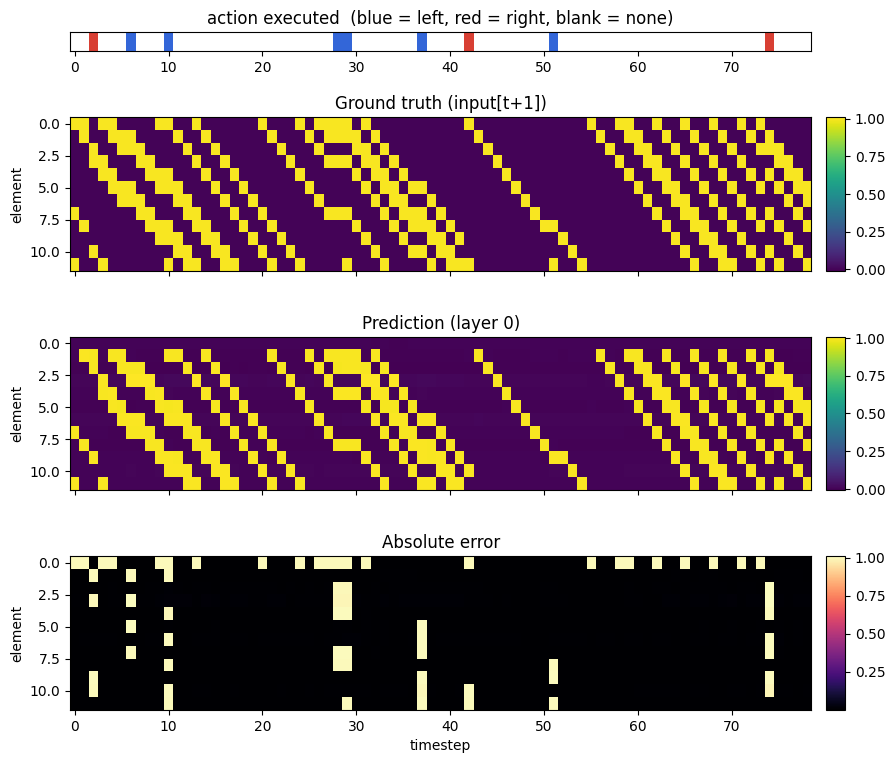

In [9]:
target = stim_target
pred_aligned = stim_pred
T = target.shape[0]
vmin = min(target.min(), pred_aligned.min())
vmax = max(target.max(), pred_aligned.max())

# action[j] produced target column j (which is input[j+1]).
plot_panels_with_actions(
    panels=[
        {'title': 'Ground truth (input[t+1])', 'data': target,
         'cmap': 'viridis', 'vmin': vmin, 'vmax': vmax},
        {'title': 'Prediction (layer 0)', 'data': pred_aligned,
         'cmap': 'viridis', 'vmin': vmin, 'vmax': vmax},
        {'title': 'Absolute error', 'data': np.abs(pred_aligned - target),
         'cmap': 'magma'},
    ],
    strip_actions=acts_eval[:T],
)

### Latent-space activity for every layer

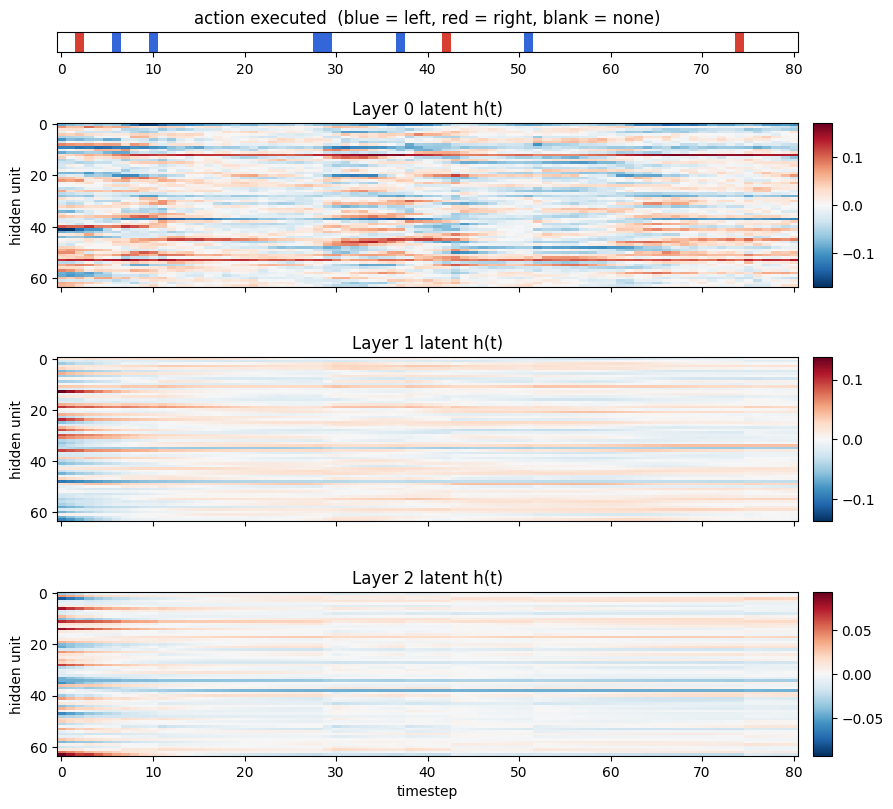

In [10]:
# Latent states are h(0..T); annotate each state column with the action taken
# from it (the final state has no following action).
S = hidden[0].shape[0]
strip_latent = np.append(acts_eval[:S - 1], NONE)

panels = []
for i in range(NUM_LAYERS):
    scale = np.abs(hidden[i]).max()
    panels.append({'title': f'Layer {i} latent h(t)', 'data': hidden[i], 'cmap': 'RdBu_r',
                   'vmin': -scale, 'vmax': scale, 'ylabel': 'hidden unit'})
plot_panels_with_actions(panels, strip_latent, panel_height=2.8)

### Higher layers: predicting the latent trajectory below

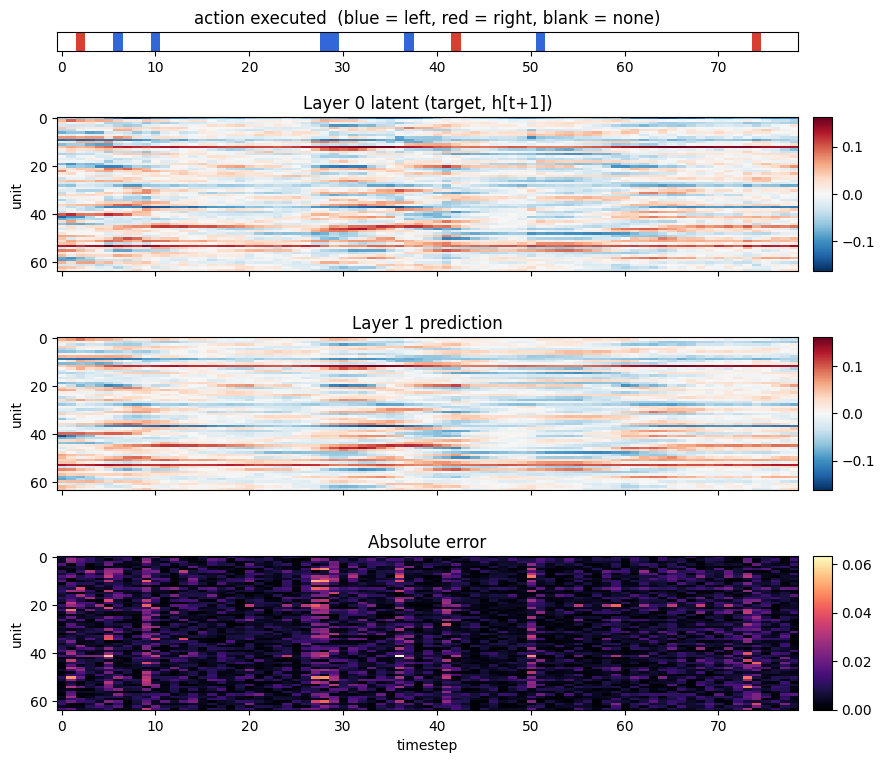

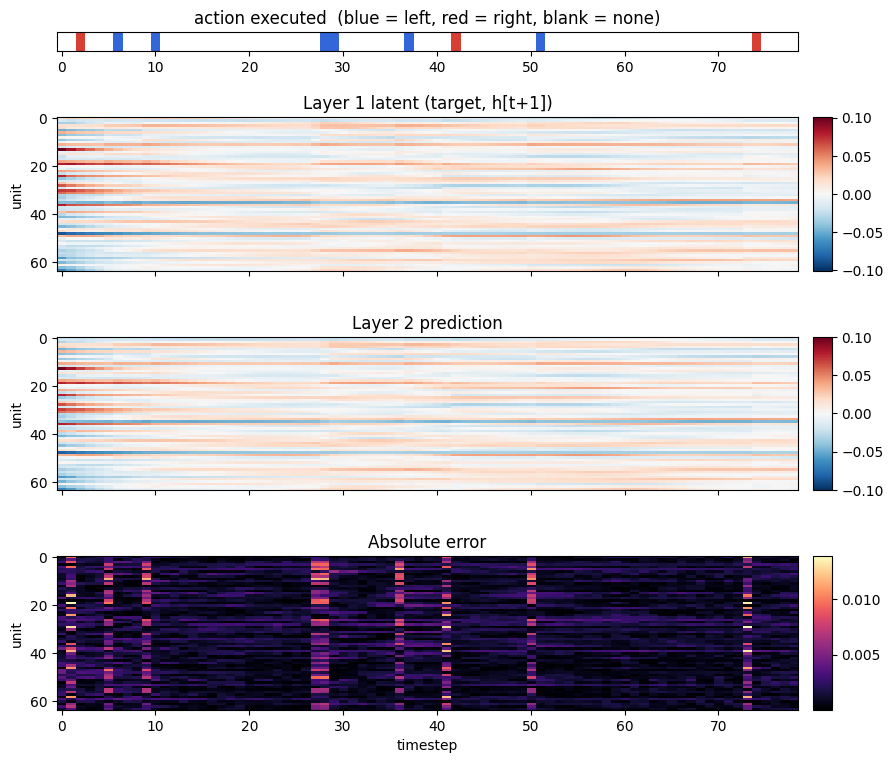

In [11]:
for i in range(1, NUM_LAYERS):
    tgt = inputs[i][1:]
    prd = preds[i][:-1]
    Ti = tgt.shape[0]
    scale = np.abs(np.concatenate([tgt, prd])).max()
    plot_panels_with_actions(
        panels=[
            {'title': f'Layer {i-1} latent (target, h[t+1])', 'data': tgt,
             'cmap': 'RdBu_r', 'vmin': -scale, 'vmax': scale, 'ylabel': 'unit'},
            {'title': f'Layer {i} prediction', 'data': prd,
             'cmap': 'RdBu_r', 'vmin': -scale, 'vmax': scale, 'ylabel': 'unit'},
            {'title': 'Absolute error', 'data': np.abs(prd - tgt),
             'cmap': 'magma', 'ylabel': 'unit'},
        ],
        strip_actions=acts_eval[:Ti],
    )